# Lab 8: Putting it all together!

**How you will be graded**

This activity is out of 10 points. You will be graded on three things: completion, clear documentation, and correctness of your process.

* *Completion (4pts)*: This is solely whether you attempted and completed all portions of the computational assignment.
* *Documentation (4pts)*: Write comments above your code, describing what it does to demonstrate that you understand what the code is doing.
* *Correctness (2pts)*: Does your code run and produce the correct output?


# Playground!

In this section you will be given a set of tasks to complete on your own, and you will have to figure out how to do them using the resources provided (videos, documentation, etc). This way you can learn at your own pace and also get used to looking up documentation and learning how to use new tools on your own.

The very first task is to import the required packages, this lab we will use all the concepts from previous labs to analyze a real biological network, everything here has been done in previous labs, so the amount of help in the notebook will be minimal (but you can still call me over if you get stuck!).

Try importing the required libraries below (dont forget you can use the `as` keyword to give them a shorter alias):

In [28]:
import networkx as nx
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

# 1. Loading data

The very first step for any analyses is to load the data and create a network out of it. Our network of choice is the gap junction network for ***C. elegans***, below is the description from its website:

'Networks among neurons of both the adult male and adult hermaphrodite worms ***C. elegans***, constructed from electron microscopy series, to include directed edges (chemical) and undirected (gap junction), and spanning including nodes for muscle and non-muscle end organs.

The 'connectivity' edge property corresponds to the total number of EM serial sections of connectivity, taking into account both the number of synapses and the sizes of synapses.

To provide complete coverage of the entire nervous system, the data are assembled from multiple animals and include connections added by extrapolation in gaps where no data were available.'

Your goal is to act like data scientists and perform some rudimentary analyses on this network, the analyses should be enough that you can inform a layman about the structure of this network.

Load the data using polars and create a graph out of it (draw the graph as well).


In [29]:
df = pl.read_csv('../data/elegans.csv')
print(df)

shape: (1_758, 3)
┌────────┬────────┬──────────────┐
│ source ┆ target ┆ connectivity │
│ ---    ┆ ---    ┆ ---          │
│ i64    ┆ i64    ┆ i64          │
╞════════╪════════╪══════════════╡
│ 2      ┆ 0      ┆ 2            │
│ 3      ┆ 1      ┆ 1            │
│ 4      ┆ 1      ┆ 1            │
│ 5      ┆ 2      ┆ 1            │
│ 8      ┆ 3      ┆ 1            │
│ …      ┆ …      ┆ …            │
│ 582    ┆ 439    ┆ 3            │
│ 582    ┆ 579    ┆ 8            │
│ 582    ┆ 581    ┆ 7            │
│ 583    ┆ 439    ┆ 4            │
│ 584    ┆ 439    ┆ 10           │
└────────┴────────┴──────────────┘


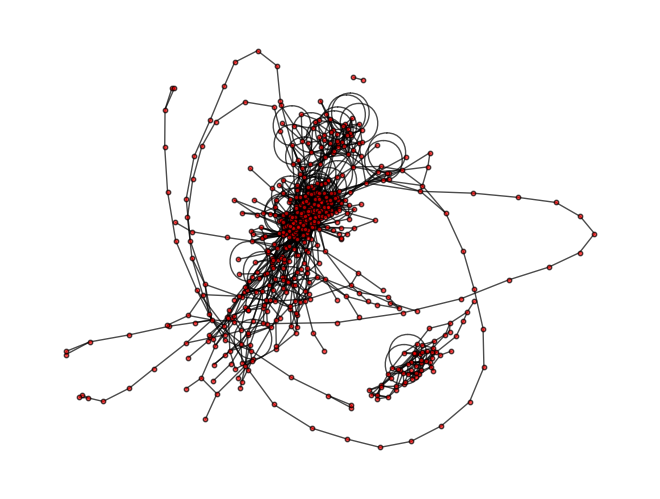

In [30]:
# TODO: Fill the blanks to directly create a graph from your df
G = nx.from_pandas_edgelist(df, source = 'source', target = 'target', edge_attr= 'connectivity')

# TODO: Draw the graph (HINT: Look at the example code)
nx.draw(G, node_color = 'red', node_size = 10, edgecolors = 'black', alpha = 0.7)

# 2. Exploring the network

When we load a new network, the very first thing we should do is explore the very basic structure of our network. This means figuring out:

- How large is this network (number of nodes and edges)?
- Is the network fully connected, or are there multiple components?
- What does the degree distribution look like at first glance?

Some of these questions can be answered just by looking at the drawn network, but thats not enough, we still should quantify all these things.

Find out and print the following statistics for your network (Dont forget to store them in seperate variables, you might need these values later):
- Number of nodes
- Number of edges
- Average degree
- Network density
- Number and size of connected components

In [31]:
stats = pl.DataFrame({
    'Number of Nodes': G.number_of_nodes(),
    'Number of Edges': G.number_of_edges(),
    'Avg Deg': sum(dict(G.degree()).values()) / G.number_of_nodes(),
    'Network Density' : nx.density(G),
    'Connected Comps Count' : nx.number_connected_components(G),
})

print(stats)
print(f'Connected Comps Size: {[len(c) for c in nx.connected_components(G)]}')

shape: (1, 5)
┌─────────────────┬─────────────────┬──────────┬─────────────────┬───────────────────────┐
│ Number of Nodes ┆ Number of Edges ┆ Avg Deg  ┆ Network Density ┆ Connected Comps Count │
│ ---             ┆ ---             ┆ ---      ┆ ---             ┆ ---                   │
│ i64             ┆ i64             ┆ f64      ┆ f64             ┆ i64                   │
╞═════════════════╪═════════════════╪══════════╪═════════════════╪═══════════════════════╡
│ 543             ┆ 1758            ┆ 6.475138 ┆ 0.011947        ┆ 3                     │
└─────────────────┴─────────────────┴──────────┴─────────────────┴───────────────────────┘
Connected Comps Size: [57, 484, 2]


# What do these number tell you? Write a line for each stat.

**Number of Nodes:** Tell us how many neurons are represented in the network; the total number of distinct entities.

**Number of Edges:** Shows how many connections exist between neurons; captures connectivity of network as well.

**Average Degree:** On average, this is how many other neurons each neuron is connected to; it reflects how densely connected the network is at the local level.

**Network Density:** This measures how close the network is to being fully connected. With $1.2\%$ density, it is not very connected.

**Connected Components Count:** This tells us how many separate subnetworks exist. In other words, how many groups of neurons are not connected to each other at all.

**Connected Components Size:** These are the sizes of those subnetworks.

# 3. Degree distribution - What type of network is this?

Now we know some basic stuff about our network, but we still dont know what kind of structure it has (except the fact that its not connected). We know from theory that biological networks tend to be scale free, i.e. their degree distribution follows a power law.

Lets check if its true for this network as well.

For this task plot the degree distribution for this network in both the linear and log scale, also plot the fit line for both graphs. 

(**Extra credits (0.5)** if you plot them side by side using `plt.subplots`)

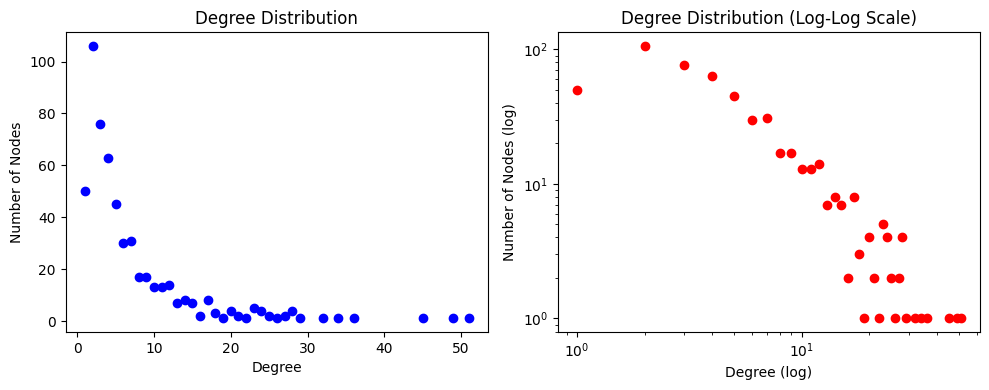

In [32]:
degrees = []
for n, d in G.degree(): # `G.degree()` returns (node, degree)
    degrees.append(d)

unique_degrees = np.unique(degrees) # Get the unique ones

counts = [] # Count how many times it appears
for k in unique_degrees:
    count = degrees.count(k)
    counts.append(count)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 4))

ax1.scatter(unique_degrees, counts, color = 'blue')

# Labelling for lin
ax1.set_title('Degree Distribution')
ax1.set_xlabel('Degree')
ax1.set_ylabel('Number of Nodes')

ax2.scatter(unique_degrees, counts, color = 'red')
ax2.set_xscale('log')
ax2.set_yscale('log')

# Labelling for log
ax2.set_title('Degree Distribution (Log-Log Scale)')
ax2.set_xlabel('Degree (log)')
ax2.set_ylabel('Number of Nodes (log)')

plt.tight_layout()
plt.show()


# Does the degree distribution resemble that of a scale-free network?  
Yes. The degree distribution does resemble that of a scale-free network. Most nodes have a low degree (few connections), while a small number of nodes have a very high degree.

# Are there a few high-degree nodes? What might that imply biologically?
Biologically, this means the neural network is likely organized around hub neurons — highly connected cells that act as central communication points. These hub neurons make the system efficient for transmitting signals but also make it vulnerable if those key nodes are damaged, since much of the network’s connectivity depends on them.




# 4. Centrality measures - Which nodes are more important?

Now that we know what type of structure we are dealing with, lets start zooming into the important components of this network. We know that a good way of figuring out which nodes are more valuable is by finding out their centrality measures, till now we have learnt about a few different types of centralities. Different centrality measures capture different ways of being “important” in a network:

In the code cell below print out the top 5 nodes for each of the following centrality measures,
- Eigenvector Centrality
- Betweenness Centrality
- Closeness Centrality

(**Hint**: Use the inbuilt networkx functions for this, its quick and practical. Look up these in the networkx documentation. For printing the top 5 nodes you can use the following code: `sorted(dict, key=dict.get, reverse=True)[:5]` where dict is your dictionary name. The output is a list of 5 nodes with the max values.)

In [ ]:
# Calculate the three types of centrality
eigen_centrality = nx.eigenvector_centrality(G)
between_centrality = nx.betweenness_centrality(G)
close_centrality = nx.closeness_centrality(G)

# Find the top 5 nodes for each measure
top5_eigen = sorted(eigen_centrality, key = eigen_centrality.get, reverse = True)[:5] # I used this `.get` thing in Lab 03 or 02 I think. Useful.
top5_between = sorted(between_centrality, key = between_centrality.get, reverse = True)[:5]
top5_close = sorted(close_centrality, key = close_centrality.get, reverse = True)[:5]

# Print the results neatly
print('Top 5 nodes by Eigenvector Centrality: {top5_eigen}')
print('Top 5 nodes by Betweenness Centrality: {top5_between}')
print('Top 5 nodes by Closeness Centrality: {top5_close}')


Top 5 nodes by Eigenvector Centrality: {top5_eigen}
Top 5 nodes by Betweenness Centrality: {top5_between}
Top 5 nodes by Closeness Centrality: {top5_close}


# Do the same nodes appear important across multiple metrics?  
Yes — some nodes, like **215**, **216**, **439**, and **504**, appear among the top results across multiple centrality measures. This means these neurons are consistently important, not just in one sense of connectivity but across different ways of measuring influence within the network.

# What might these results mean for robustness of the connectome?
Biologically, this suggests that these neurons act as **key hubs** in the connectome. They likely play major roles in coordinating communication between different parts of the nervous system. If one of these central neurons were damaged, it could disrupt the overall flow of information, showing that while the network is efficient, it’s also somewhat **vulnerable** to targeted failures.

# What does each of these measures tell you about the nodes?
Each measure highlights a different kind of importance:

* **Eigenvector centrality** identifies neurons connected to other highly connected neurons.
* **Betweenness centrality** finds neurons that serve as bridges between otherwise separate clusters. 
* **Closeness centrality** points to neurons that can reach all others quickly.





# 5. Assortativity - Do similar nodes connect?

In networks, **assortativity** measures the tendency of nodes to connect to others that are similar in some property — like degree. It ranges from `-1` to `1`.

- A **positive assortativity** means high-degree nodes tend to connect with other high-degree nodes.  
- A **negative assortativity** means high-degree nodes connect more often with low-degree ones.
- A **zero assortativity** means there is no preference.  

This property could tell us something about how the network might respond to failures or disruptions.

Your task is to use networkx's inbuilt function to find and print the assortaticity for our network.

In [34]:
assortativity = nx.degree_assortativity_coefficient(G) # Found assortavity through docs.

print('Assortativity coefficient: {assortativity}')


Assortativity coefficient: {assortativity}


# Is it assortative or disassortative?
The network has an assortativity coefficient of about $0.23$, which means it is positively assortative: high-degree neurons tend to connect with other high-degree neurons.

# How might this pattern influence the network’s robustness to node loss (random or targeted)? What about networks with high positive or negative assortativity?
This kind of structure suggests that the connectome has clusters of well-connected neurons that reinforce each other. In terms of robustness, assortative networks are generally more resistant to random node loss because they tend to affect lower degree nodes. However, they are more vulnerable to targeted attacks on the hubs, since the highly connected nodes are closely linked and their failure can fragment the network quickly.

# Why might such a structure be biologically beneficial (or not) for a system?
Biologically, a slightly positive assortativity may be beneficial because it allows groups of interconnected hub neurons to coordinate complex behavior efficiently while still maintaining some robustness. 


# 6. Putting it all together

- Reflect on your analyses and why you did it (apart from the fact that we asked you to)?
- What would you do differently if you were in a professional capacity and asked to analyse a unknown network?
- Is there a metric that was more insightful than others, and why?

This lab helped me understand how different network measures show which nodes and connections matter most. I did it to see how real biological networks like C. elegans organize and stay connected.

If I were doing this in a professional setting, I’d spend more time cleaning the data and checking that the network is accurate before running the analysis.

The most useful metric was betweenness centrality, since it clearly showed which neurons act as bridges that keep the network connected.

# Extra Credit (2 pts)

Some networks could have communities within them, we can use the function `nx.community.greedy_modularity_communities` to assign nodes to communities using the modularity maximization process.

For this extra credit I want you to list the number of communities in the network and the number of nodes in each community. 

Why do we see communities in a connectome network? What use might they be?

In [35]:
communities = nx.community.greedy_modularity_communities(G)

# Count how many communities there are
num_communities = len(communities)
print('Number of communities: {num_communities}')

# Print the size of each community
i = 1
for c in communities:
    print(f'Community {i} has {len(c)} nodes')
    i = i + 1


Number of communities: {num_communities}
Community 1 has 119 nodes
Community 2 has 113 nodes
Community 3 has 86 nodes
Community 4 has 62 nodes
Community 5 has 57 nodes
Community 6 has 52 nodes
Community 7 has 46 nodes
Community 8 has 4 nodes
Community 9 has 2 nodes
Community 10 has 2 nodes
